# Retornos por descuento vs02

Reestructuración mínima para evaluar descuentos como screening económico: compara kilos observados contra un baseline diario sin promoción, calcula break-even, BCR, ROI neto, sensibilidad y banderas de calidad. Esta versión no pretende estimar causalidad.

## 0. Configuración

In [1]:
from pathlib import Path
from collections import defaultdict
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", message=".*SettingWithCopyWarning.*")

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("datos")
PATH_VENTAS = DATA_DIR / "Ventas por Cliente" / "ventas_con_descuento_aplicado.csv"
PATH_DESCUENTOS = DATA_DIR / "Descuentos históricos" / "consolidado_descuentos.csv"
PATH_COSTOS = DATA_DIR / "Consolidado ABC SKU (oct25'-mar26') FINAL.xlsx"

OUTPUT_RAW = DATA_DIR / "resultados_retornos_raw_vs02.csv"
OUTPUT_FILTRADO = DATA_DIR / "resultados_retornos_filtrados_vs02.csv"
OUTPUT_OUTLIERS = DATA_DIR / "outliers_retornos_vs02.csv"

MAX_DURACION_DIAS = 60
MIN_DIAS_BASELINE_ALTA = 30
MIN_DIAS_BASELINE_MEDIA = 14
ID_DESCUENTO_EJEMPLO = "70"

KEY_COLS = ["cod_sku_key", "cod_canal_key", "cod_consolidado_key"]


## 1. Carga y normalización de datos

In [2]:
def normalizar_codigo_serie(serie):
    """Normaliza códigos para evitar fallas por int/float/string entre fuentes."""
    normalizada = serie.astype("string").str.strip()
    normalizada = normalizada.str.replace(r"\.0$", "", regex=True)
    normalizada = normalizada.mask(normalizada.isin(["", "nan", "NaN", "None", "<NA>"]))
    return normalizada


def normalizar_codigo_valor(valor):
    if pd.isna(valor):
        return pd.NA
    texto = str(valor).strip()
    if texto.endswith(".0"):
        texto = texto[:-2]
    return pd.NA if texto in {"", "nan", "NaN", "None", "<NA>"} else texto


def dividir_seguro(numerador, denominador):
    return np.where(
        (pd.notna(denominador)) & (denominador != 0),
        numerador / denominador,
        np.nan,
    )


In [3]:
USECOLS_VENTAS = [
    "fecha_factura", "cod_sku", "cod_canal_comercial", "cod_consolidado",
    "kilo_real", "precio_real", "descuento_aplicado", "id_descuento_aplicado",
    "costo_descuento",
]
DTYPES_VENTAS = {
    "cod_sku": "string",
    "cod_canal_comercial": "string",
    "cod_consolidado": "string",
    "descuento_aplicado": "string",
    "id_descuento_aplicado": "string",
}
ventas = pd.read_csv(PATH_VENTAS, usecols=USECOLS_VENTAS, dtype=DTYPES_VENTAS, low_memory=True)
ventas["fecha_factura"] = pd.to_datetime(ventas["fecha_factura"], errors="coerce")
ventas["cod_sku_key"] = normalizar_codigo_serie(ventas["cod_sku"])
ventas["cod_canal_key"] = normalizar_codigo_serie(ventas["cod_canal_comercial"])
ventas["cod_consolidado_key"] = normalizar_codigo_serie(ventas["cod_consolidado"])
ventas["id_descuento_key"] = normalizar_codigo_serie(ventas["id_descuento_aplicado"])
ventas["descuento_aplicado_norm"] = ventas["descuento_aplicado"].astype("string").str.strip().str.lower().fillna("ninguno")

for col in ["kilo_real", "precio_real", "costo_descuento", "monto_real", "precio_lista"]:
    if col in ventas.columns:
        ventas[col] = pd.to_numeric(ventas[col], errors="coerce")

ventas["kilo_real"] = ventas["kilo_real"].fillna(0)
ventas["costo_descuento"] = ventas["costo_descuento"].fillna(0)
fecha_min_ventas = ventas["fecha_factura"].min()
fecha_max_ventas = ventas["fecha_factura"].max()

print("Ventas - filas:", ventas.shape[0])
print("Rango ventas:", fecha_min_ventas, "a", fecha_max_ventas)
ventas.head()


Ventas - filas: 9638476
Rango ventas: 2025-01-02 00:00:00 a 2026-04-08 00:00:00


,cod_canal_comercial,cod_consolidado,fecha_factura,cod_sku,kilo_real,precio_real,descuento_aplicado,id_descuento_aplicado,costo_descuento,cod_sku_key,cod_canal_key,cod_consolidado_key,id_descuento_key,descuento_aplicado_norm
0,CB,32,2025-01-02,3034,4.00,"10,860.00",base_forzado,<NA>,"2,712.00",3034,CB,32,<NA>,base_forzado
1,HR,55,2025-01-03,399,12.00,"2,634.00",base,2352,972.00,399,HR,55,2352,base
2,HR,37,2025-01-03,1006,30.40,"2,722.01",ninguno,<NA>,-0.20,1006,HR,37,<NA>,ninguno
3,CB,32,2025-01-02,3991,2.40,"4,525.83",base,2372,"1,548.40",3991,CB,32,2372,base
4,HR,55,2025-01-03,1446,4.80,"3,135.00",base_forzado,<NA>,465.60,1446,HR,55,<NA>,base_forzado


In [4]:
descuentos = pd.read_csv(PATH_DESCUENTOS, low_memory=False)
descuentos["fecha_fin_original"] = descuentos["fecha_fin"].astype("string")
descuentos["fecha_inicio"] = pd.to_datetime(descuentos["fecha_inicio"], errors="coerce")
descuentos["fecha_fin"] = pd.to_datetime(descuentos["fecha_fin"], errors="coerce")
descuentos["flag_fecha_abierta"] = descuentos["fecha_fin_original"].str.startswith("9999", na=False) | descuentos["fecha_fin"].isna()
descuentos["fecha_fin_baseline"] = descuentos["fecha_fin"].where(~descuentos["flag_fecha_abierta"], fecha_max_ventas)

descuentos["cod_sku_key"] = normalizar_codigo_serie(descuentos["cod_sku"])
descuentos["cod_canal_key"] = normalizar_codigo_serie(descuentos["cod_canal"])
descuentos["cod_consolidado_key"] = normalizar_codigo_serie(descuentos["cod_consolidado"])
descuentos["id_descuento_key"] = normalizar_codigo_serie(descuentos["id_descuento"])
descuentos["tipo_descuento_norm"] = descuentos["tipo_descuento"].astype("string").str.strip().str.lower()
descuentos["monto_descuento"] = pd.to_numeric(descuentos["monto_descuento"], errors="coerce")

cod_consolidado_ventas = set(ventas["cod_consolidado_key"].dropna().unique())
mask_base_descuentos = (
    (descuentos["monto_descuento"] < 0)
    & (descuentos["tipo_descuento_norm"] != "carta_impacto")
    & (descuentos["cod_consolidado_key"].isin(cod_consolidado_ventas))
    & (descuentos["fecha_inicio"].dt.year >= 2025)
)

descuentos_candidatos = descuentos.loc[mask_base_descuentos].copy()
descuentos_candidatos["duracion_dias"] = (
    descuentos_candidatos["fecha_fin"] - descuentos_candidatos["fecha_inicio"]
).dt.days + 1

print("Descuentos candidatos:", descuentos_candidatos.shape[0])
descuentos_candidatos.head()


Descuentos candidatos: 3636


,id_descuento,tipo_descuento,cod_sku,cod_canal,cod_consolidado,cod_cliente,fecha_inicio,fecha_fin,monto_descuento,__source_order,fecha_fin_original,flag_fecha_abierta,fecha_fin_baseline,cod_sku_key,cod_canal_key,cod_consolidado_key,id_descuento_key,tipo_descuento_norm,duracion_dias
69,70,base,1020,MY,38.00,NaN,2025-01-01,2025-01-31,-3.00,2385,2025-01-31,False,2025-01-31,1020,MY,38,70,base,31
70,71,base,1020,MY,38.00,NaN,2025-02-01,2025-02-28,-12.70,2386,2025-02-28,False,2025-02-28,1020,MY,38,71,base,28
71,72,base,1020,MY,38.00,NaN,2025-03-01,2026-03-31,-3.00,2387,2026-03-31,False,2026-03-31,1020,MY,38,72,base,396
85,86,base,1020,MY,57.00,NaN,2025-01-01,2025-01-31,-6.00,2844,2025-01-31,False,2025-01-31,1020,MY,57,86,base,31
86,87,base,1020,MY,57.00,NaN,2025-02-01,2025-02-28,-15.40,2845,2025-02-28,False,2025-02-28,1020,MY,57,87,base,28


In [5]:
lista_dfs_costos = []
xls = pd.ExcelFile(PATH_COSTOS, engine="openpyxl")
for sheet_name in xls.sheet_names:
    df = pd.read_excel(xls, sheet_name=sheet_name, engine="openpyxl")
    df["Mes"] = sheet_name
    lista_dfs_costos.append(df)

costos = pd.concat(lista_dfs_costos, ignore_index=True)
cols_costos = [
    "Mes", "SKU", " Kilos Finales", "Facturación", "Aporte", "Costo",
    "Frío Externo", "Energía", "Distribución Fijo", "T Producción",
    "Gastos DM Canales", "Gastos DM Marketing", "Reponer",
    "Gastos. Zonales Directos", "O. G. Fijos Indirectos",
    "Otros Distribución Variable",
]
costos = costos[[col for col in cols_costos if col in costos.columns]].copy()
costos["SKU_key"] = normalizar_codigo_serie(costos["SKU"])

cols_numericas_costos = [col for col in costos.columns if col not in ["Mes", "SKU", "SKU_key"]]
for col in cols_numericas_costos:
    costos[col] = pd.to_numeric(costos[col], errors="coerce").fillna(0)

costos_totales = costos.groupby("SKU_key", as_index=False)[cols_numericas_costos].sum()
costos_totales["Margen Producción"] = (
    costos_totales["Facturación"]
    - costos_totales["Costo"]
    - costos_totales["Distribución Fijo"]
    - costos_totales["Frío Externo"]
)
costos_totales["Margen por Kilo"] = costos_totales["Margen Producción"] / costos_totales[" Kilos Finales"].replace(0, np.nan)
margen_por_sku = costos_totales.set_index("SKU_key")["Margen por Kilo"]

print("Costos - filas:", costos.shape[0])
costos_totales.head()


Costos - filas: 1362


,SKU_key,Kilos Finales,Facturación,Aporte,Costo,Frío Externo,Energía,Distribución Fijo,T Producción,Gastos DM Canales,Gastos DM Marketing,Reponer,Gastos. Zonales Directos,O. G. Fijos Indirectos,Otros Distribución Variable,Margen Producción,Margen por Kilo
0,1006,"96,297.70",291465090,"8,116,701.00","98,958,609.85","739,719.83","7,617,034.65","5,363,597.74","41,277,537.87","557,186.92","4,496,381.23","3,226,585.86","8,445,123.71","19,804,172.05","557,741.63","186,403,162.59","1,935.70"
1,1018,"85,574.00",213886521,"25,097,295.00","85,122,883.96","658,372.19","6,766,160.17","4,765,196.33","31,316,642.07","565,336.59","3,237,652.07","7,415,013.77","4,461,032.12","14,943,113.11","1,426,421.14","123,340,068.52","1,441.33"
2,1019,"542,006.00",1211209726,"161,934,981.00","437,132,200.40","4,166,218.27","42,699,763.70","30,183,122.73","195,330,491.12","4,406,995.96","18,391,629.57","64,850,874.10","31,134,819.92","86,449,201.79","9,362,209.43","739,728,184.60","1,364.80"
3,102,"76,809.93",431581113,"33,333,712.00","173,620,556.00","1,609,274.85","8,061,725.21","4,282,383.61","18,215,980.20","2,161,787.03","6,481,077.26","5,942,075.96","11,082,872.83","27,182,730.95","4,919,938.56","252,068,898.54","3,281.72"
4,1020,"2,327,798.17",6277644323,"368,722,410.00","2,090,317,174.77","17,766,554.31","199,142,796.70","129,792,882.83","1,162,004,677.68","16,175,632.87","95,307,864.85","131,554,399.27","140,256,100.91","433,296,171.38","46,496,003.68","4,039,767,711.09","1,735.45"


In [6]:
# Preagregaciones para evitar escanear toda la tabla de ventas en cada descuento.
llaves_candidatas = descuentos_candidatos[KEY_COLS].drop_duplicates()
ventas_relevantes = ventas.merge(llaves_candidatas, on=KEY_COLS, how="inner")

ventas_por_llave = {
    tuple(key): grupo.copy()
    for key, grupo in ventas_relevantes.groupby(KEY_COLS, dropna=False, sort=False)
}

observados_por_descuento = (
    ventas_relevantes.dropna(subset=["id_descuento_key"])
    .groupby(KEY_COLS + ["id_descuento_key"], dropna=False, as_index=False)
    .agg(
        kg_observados=("kilo_real", "sum"),
        costo_promocion=("costo_descuento", "sum"),
    )
)
observados_lookup = {
    (
        row.cod_sku_key,
        row.cod_canal_key,
        row.cod_consolidado_key,
        row.id_descuento_key,
    ): (float(row.kg_observados), float(row.costo_promocion))
    for row in observados_por_descuento.itertuples(index=False)
}

print("Ventas relevantes:", ventas_relevantes.shape[0])
print("Llaves candidatas con ventas:", len(ventas_por_llave))
print("Pares llave-descuento observados:", len(observados_lookup))


Ventas relevantes: 8582700
Llaves candidatas con ventas: 754
Pares llave-descuento observados: 3739


## 2. Baseline diario sin promoción

El baseline mantiene la lógica original de demanda diaria sin descuento, pero corrige dos puntos: usa un calendario diario con ceros entre la primera y última venta observada de la llave, y excluye días con cualquier promoción activa para la misma llave SKU-canal-consolidado.

In [7]:
def construir_dias_promocion_por_llave(descuentos_base):
    dias_por_llave = defaultdict(set)
    columnas = KEY_COLS + ["fecha_inicio", "fecha_fin_baseline"]
    descuentos_validos = descuentos_base.dropna(subset=columnas).copy()

    for row in descuentos_validos[columnas].itertuples(index=False):
        sku, canal, consolidado, fecha_inicio, fecha_fin = row
        inicio = max(fecha_inicio.normalize(), fecha_min_ventas.normalize())
        fin = min(fecha_fin.normalize(), fecha_max_ventas.normalize())
        if pd.isna(inicio) or pd.isna(fin) or inicio > fin:
            continue
        llave = (sku, canal, consolidado)
        dias_por_llave[llave].update(pd.date_range(inicio, fin, freq="D"))

    return dias_por_llave


dias_promocion_por_llave = construir_dias_promocion_por_llave(descuentos_candidatos)
print("Llaves con días promocionales:", len(dias_promocion_por_llave))


Llaves con días promocionales: 848


In [8]:
baseline_cache = {}


def filtrar_ventas_llave(sku, canal, consolidado):
    llave = (sku, canal, consolidado)
    ventas_llave = ventas_por_llave.get(llave)
    if ventas_llave is None:
        return ventas_relevantes.iloc[0:0].copy()
    return ventas_llave.copy()


def calcular_baseline_llave(sku, canal, consolidado):
    llave = (sku, canal, consolidado)
    if llave in baseline_cache:
        return baseline_cache[llave]

    ventas_llave = filtrar_ventas_llave(sku, canal, consolidado)
    if ventas_llave.empty or ventas_llave["fecha_factura"].isna().all():
        resultado = {
            "baseline_metodo": "sin_ventas_llave",
            "dias_baseline": 0,
            "dias_venta_baseline": 0,
            "kg_baseline_diario": np.nan,
            "kg_baseline_p25": np.nan,
            "kg_baseline_p75": np.nan,
            "kg_baseline_total_muestra": np.nan,
            "precio_maximo_muestra": np.nan,
            "fecha_inicio_panel": pd.NaT,
            "fecha_fin_panel": pd.NaT,
        }
        baseline_cache[llave] = resultado
        return resultado

    ventas_llave = ventas_llave.dropna(subset=["fecha_factura"]).copy()
    fecha_inicio_panel = ventas_llave["fecha_factura"].min().normalize()
    fecha_fin_panel = ventas_llave["fecha_factura"].max().normalize()
    calendario = pd.DataFrame({"fecha_factura": pd.date_range(fecha_inicio_panel, fecha_fin_panel, freq="D")})

    precio_maximo = ventas_llave["precio_real"].max()
    ventas_llave["es_sin_descuento"] = ventas_llave["descuento_aplicado_norm"].eq("ninguno")
    ventas_llave["es_precio_maximo"] = np.isclose(
        ventas_llave["precio_real"].fillna(-np.inf),
        precio_maximo,
        rtol=0,
        atol=1e-6,
    )
    ventas_llave["kg_sin_descuento"] = np.where(ventas_llave["es_sin_descuento"], ventas_llave["kilo_real"], 0)
    ventas_llave["kg_precio_maximo"] = np.where(ventas_llave["es_precio_maximo"], ventas_llave["kilo_real"], 0)

    diario = (
        ventas_llave.groupby("fecha_factura", as_index=False)
        .agg(
            kg_total=("kilo_real", "sum"),
            kg_sin_descuento=("kg_sin_descuento", "sum"),
            kg_precio_maximo=("kg_precio_maximo", "sum"),
            ventas_sin_descuento=("es_sin_descuento", "sum"),
            ventas_precio_maximo=("es_precio_maximo", "sum"),
        )
    )

    panel = calendario.merge(diario, on="fecha_factura", how="left").fillna({
        "kg_total": 0,
        "kg_sin_descuento": 0,
        "kg_precio_maximo": 0,
        "ventas_sin_descuento": 0,
        "ventas_precio_maximo": 0,
    })

    dias_promo = dias_promocion_por_llave.get(llave, set())
    panel["flag_promo_activa_llave"] = panel["fecha_factura"].isin(dias_promo)
    panel_elegible = panel.loc[~panel["flag_promo_activa_llave"]].copy()

    hay_ventas_sin_descuento = panel_elegible["ventas_sin_descuento"].sum() > 0
    if hay_ventas_sin_descuento:
        baseline_metodo = "sin_descuento_calendario"
        serie_kg = panel_elegible["kg_sin_descuento"]
    else:
        baseline_metodo = "precio_maximo_calendario"
        panel_precio_maximo = panel_elegible.loc[panel_elegible["ventas_precio_maximo"] > 0].copy()
        origen_fallback = panel_elegible
        if panel_precio_maximo.empty:
            panel_precio_maximo = panel.loc[panel["ventas_precio_maximo"] > 0].copy()
            origen_fallback = panel

        if panel_precio_maximo.empty:
            serie_kg = pd.Series(dtype="float64")
        else:
            calendario_fallback = pd.DataFrame({
                "fecha_factura": pd.date_range(
                    panel_precio_maximo["fecha_factura"].min(),
                    panel_precio_maximo["fecha_factura"].max(),
                    freq="D",
                )
            })
            serie_kg = (
                calendario_fallback
                .merge(origen_fallback[["fecha_factura", "kg_precio_maximo"]], on="fecha_factura", how="left")
                ["kg_precio_maximo"]
                .fillna(0)
            )

    dias_baseline = int(serie_kg.shape[0])
    if dias_baseline > 0:
        kg_baseline_diario = float(serie_kg.mean())
        kg_baseline_p25 = float(serie_kg.quantile(0.25))
        kg_baseline_p75 = float(serie_kg.quantile(0.75))
        kg_baseline_total_muestra = float(serie_kg.sum())
        dias_venta_baseline = int((serie_kg > 0).sum())
    else:
        kg_baseline_diario = np.nan
        kg_baseline_p25 = np.nan
        kg_baseline_p75 = np.nan
        kg_baseline_total_muestra = np.nan
        dias_venta_baseline = 0

    resultado = {
        "baseline_metodo": baseline_metodo,
        "dias_baseline": dias_baseline,
        "dias_venta_baseline": dias_venta_baseline,
        "kg_baseline_diario": kg_baseline_diario,
        "kg_baseline_p25": kg_baseline_p25,
        "kg_baseline_p75": kg_baseline_p75,
        "kg_baseline_total_muestra": kg_baseline_total_muestra,
        "precio_maximo_muestra": precio_maximo,
        "fecha_inicio_panel": fecha_inicio_panel,
        "fecha_fin_panel": fecha_fin_panel,
    }
    baseline_cache[llave] = resultado
    return resultado


## 3. Solapamientos y análisis por descuento

In [9]:
def marcar_solapamientos(descuentos_base):
    flags = pd.Series(False, index=descuentos_base.index)
    descuentos_validos = descuentos_base.dropna(subset=KEY_COLS + ["fecha_inicio", "fecha_fin"]).copy()

    for _, grupo in descuentos_validos.groupby(KEY_COLS, dropna=False):
        activos = []
        grupo_ordenado = grupo.sort_values(["fecha_inicio", "fecha_fin"])
        for idx, row in grupo_ordenado.iterrows():
            activos = [(idx_activo, fin_activo) for idx_activo, fin_activo in activos if fin_activo >= row["fecha_inicio"]]
            if activos:
                flags.loc[idx] = True
                flags.loc[[idx_activo for idx_activo, _ in activos]] = True
            activos.append((idx, row["fecha_fin"]))

    return flags


descuentos_candidatos["flag_solapamiento"] = marcar_solapamientos(descuentos_candidatos)
print("Descuentos con solapamiento:", int(descuentos_candidatos["flag_solapamiento"].sum()))


Descuentos con solapamiento: 2309


In [10]:
def clasificar_valor(row):
    if not row["flag_evaluable"]:
        return "no evaluable"
    if row["contribucion_neta_baseline_alto"] > 0:
        return "crea valor"
    if row["contribucion_neta_baseline_bajo"] <= 0:
        return "destruye valor"
    return "incierto"


def clasificar_calidad(row):
    if not row["flag_evaluable"]:
        return "baja"
    if row["flag_solapamiento"] or row["dias_baseline"] < MIN_DIAS_BASELINE_MEDIA:
        return "baja"
    if row["baseline_metodo"] == "precio_maximo_calendario" or row["dias_baseline"] < MIN_DIAS_BASELINE_ALTA:
        return "media"
    return "alta"


def analizar_descuento(descuento):
    id_descuento = descuento["id_descuento"]
    id_descuento_key = descuento["id_descuento_key"]
    sku = descuento["cod_sku_key"]
    canal = descuento["cod_canal_key"]
    consolidado = descuento["cod_consolidado_key"]
    fecha_inicio = descuento["fecha_inicio"]
    fecha_fin = descuento["fecha_fin"]
    duracion_dias = descuento["duracion_dias"]

    margen_por_kg = margen_por_sku.get(sku, np.nan)
    flag_fecha_valida = pd.notna(fecha_inicio) and pd.notna(fecha_fin) and not bool(descuento["flag_fecha_abierta"])
    flag_duracion_valida = flag_fecha_valida and pd.notna(duracion_dias) and duracion_dias > 0
    flag_duracion_en_rango = flag_duracion_valida and duracion_dias <= MAX_DURACION_DIAS
    flag_margen_valido = pd.notna(margen_por_kg) and margen_por_kg > 0

    baseline = calcular_baseline_llave(sku, canal, consolidado)
    flag_baseline_valido = pd.notna(baseline["kg_baseline_diario"]) and baseline["dias_baseline"] > 0

    kg_observados, costo_promocion = observados_lookup.get(
        (sku, canal, consolidado, id_descuento_key),
        (0.0, 0.0),
    )
    flag_costo_positivo = costo_promocion > 0

    if flag_duracion_valida and flag_baseline_valido:
        kg_baseline_total = baseline["kg_baseline_diario"] * duracion_dias
        kg_baseline_bajo_total = baseline["kg_baseline_p25"] * duracion_dias
        kg_baseline_alto_total = baseline["kg_baseline_p75"] * duracion_dias
    else:
        kg_baseline_total = np.nan
        kg_baseline_bajo_total = np.nan
        kg_baseline_alto_total = np.nan

    kg_incremental = kg_observados - kg_baseline_total if pd.notna(kg_baseline_total) else np.nan
    kg_incremental_baseline_bajo = kg_observados - kg_baseline_bajo_total if pd.notna(kg_baseline_bajo_total) else np.nan
    kg_incremental_baseline_alto = kg_observados - kg_baseline_alto_total if pd.notna(kg_baseline_alto_total) else np.nan

    margen_incremental_bruto = kg_incremental * margen_por_kg if flag_margen_valido and pd.notna(kg_incremental) else np.nan
    margen_incremental_baseline_bajo = kg_incremental_baseline_bajo * margen_por_kg if flag_margen_valido and pd.notna(kg_incremental_baseline_bajo) else np.nan
    margen_incremental_baseline_alto = kg_incremental_baseline_alto * margen_por_kg if flag_margen_valido and pd.notna(kg_incremental_baseline_alto) else np.nan

    contribucion_neta = margen_incremental_bruto - costo_promocion if pd.notna(margen_incremental_bruto) else np.nan
    contribucion_neta_baseline_bajo = margen_incremental_baseline_bajo - costo_promocion if pd.notna(margen_incremental_baseline_bajo) else np.nan
    contribucion_neta_baseline_alto = margen_incremental_baseline_alto - costo_promocion if pd.notna(margen_incremental_baseline_alto) else np.nan

    bcr = margen_incremental_bruto / costo_promocion if flag_costo_positivo and pd.notna(margen_incremental_bruto) else np.nan
    roi_neto = contribucion_neta / costo_promocion if flag_costo_positivo and pd.notna(contribucion_neta) else np.nan
    kg_break_even = costo_promocion / margen_por_kg if flag_costo_positivo and flag_margen_valido else np.nan
    ratio_cobertura = kg_incremental / kg_break_even if pd.notna(kg_break_even) and kg_break_even != 0 and pd.notna(kg_incremental) else np.nan

    flag_evaluable = bool(
        flag_fecha_valida
        and flag_duracion_valida
        and flag_duracion_en_rango
        and flag_costo_positivo
        and flag_margen_valido
        and flag_baseline_valido
    )

    resultado = {
        "id_descuento": id_descuento,
        "id_descuento_key": id_descuento_key,
        "tipo_descuento": descuento["tipo_descuento"],
        "cod_sku": descuento["cod_sku"],
        "cod_canal": descuento["cod_canal"],
        "cod_consolidado": descuento["cod_consolidado"],
        "cod_sku_key": sku,
        "cod_canal_key": canal,
        "cod_consolidado_key": consolidado,
        "fecha_inicio": fecha_inicio,
        "fecha_fin": fecha_fin,
        "duracion_dias": duracion_dias,
        "flag_fecha_abierta": bool(descuento["flag_fecha_abierta"]),
        "flag_fecha_valida": flag_fecha_valida,
        "flag_duracion_valida": flag_duracion_valida,
        "flag_duracion_en_rango": flag_duracion_en_rango,
        "flag_solapamiento": bool(descuento["flag_solapamiento"]),
        "flag_costo_positivo": flag_costo_positivo,
        "flag_margen_valido": flag_margen_valido,
        "flag_baseline_valido": flag_baseline_valido,
        "flag_evaluable": flag_evaluable,
        **baseline,
        "kg_observados": kg_observados,
        "kg_baseline_total": kg_baseline_total,
        "kg_baseline_bajo_total": kg_baseline_bajo_total,
        "kg_baseline_alto_total": kg_baseline_alto_total,
        "kg_incremental": kg_incremental,
        "kg_incremental_baseline_bajo": kg_incremental_baseline_bajo,
        "kg_incremental_baseline_alto": kg_incremental_baseline_alto,
        "margen_por_kg_utilizado": margen_por_kg,
        "margen_incremental_bruto": margen_incremental_bruto,
        "margen_incremental_baseline_bajo": margen_incremental_baseline_bajo,
        "margen_incremental_baseline_alto": margen_incremental_baseline_alto,
        "costo_promocion": costo_promocion,
        "contribucion_neta": contribucion_neta,
        "contribucion_neta_baseline_bajo": contribucion_neta_baseline_bajo,
        "contribucion_neta_baseline_alto": contribucion_neta_baseline_alto,
        "BCR": bcr,
        "ROI_neto": roi_neto,
        "kg_break_even": kg_break_even,
        "ratio_cobertura": ratio_cobertura,
    }
    return resultado


In [11]:
resultados = []
for descuento in descuentos_candidatos.to_dict("records"):
    resultados.append(analizar_descuento(descuento))

resultados_df = pd.DataFrame(resultados)
resultados_df["clasificacion_valor"] = resultados_df.apply(clasificar_valor, axis=1)
resultados_df["calidad_contrafactual"] = resultados_df.apply(clasificar_calidad, axis=1)

print("Descuentos analizados:", resultados_df.shape[0])
print("Evaluables:", int(resultados_df["flag_evaluable"].sum()))
resultados_df.head()


Descuentos analizados: 3636
Evaluables: 1901


,id_descuento,id_descuento_key,tipo_descuento,cod_sku,cod_canal,cod_consolidado,cod_sku_key,cod_canal_key,cod_consolidado_key,fecha_inicio,fecha_fin,duracion_dias,flag_fecha_abierta,flag_fecha_valida,flag_duracion_valida,flag_duracion_en_rango,flag_solapamiento,flag_costo_positivo,flag_margen_valido,flag_baseline_valido,flag_evaluable,baseline_metodo,dias_baseline,dias_venta_baseline,kg_baseline_diario,kg_baseline_p25,kg_baseline_p75,kg_baseline_total_muestra,precio_maximo_muestra,fecha_inicio_panel,fecha_fin_panel,kg_observados,kg_baseline_total,kg_baseline_bajo_total,kg_baseline_alto_total,kg_incremental,kg_incremental_baseline_bajo,kg_incremental_baseline_alto,margen_por_kg_utilizado,margen_incremental_bruto,margen_incremental_baseline_bajo,margen_incremental_baseline_alto,costo_promocion,contribucion_neta,contribucion_neta_baseline_bajo,contribucion_neta_baseline_alto,BCR,ROI_neto,kg_break_even,ratio_cobertura,clasificacion_valor,calidad_contrafactual
0,70,70,base,1020,MY,38.00,1020,MY,38,2025-01-01,2025-01-31,31,False,True,True,True,False,True,True,True,True,precio_maximo_calendario,1,1,5.00,5.00,5.00,5.00,"2,973.20",2025-01-02,2026-04-07,"6,095.00",155.00,155.00,155.00,"5,940.00","5,940.00","5,940.00","1,735.45","10,308,548.44","10,308,548.44","10,308,548.44","518,086.00","9,790,462.44","9,790,462.44","9,790,462.44",19.90,18.90,298.53,19.90,crea valor,baja
1,71,71,base,1020,MY,38.00,1020,MY,38,2025-02-01,2025-02-28,28,False,True,True,True,False,True,True,True,True,precio_maximo_calendario,1,1,5.00,5.00,5.00,5.00,"2,973.20",2025-01-02,2026-04-07,"4,880.00",140.00,140.00,140.00,"4,740.00","4,740.00","4,740.00","1,735.45","8,226,013.40","8,226,013.40","8,226,013.40","1,761,681.00","6,464,332.40","6,464,332.40","6,464,332.40",4.67,3.67,"1,015.12",4.67,crea valor,baja
2,72,72,base,1020,MY,38.00,1020,MY,38,2025-03-01,2026-03-31,396,False,True,True,False,True,True,True,True,False,precio_maximo_calendario,1,1,5.00,5.00,5.00,5.00,"2,973.20",2025-01-02,2026-04-07,"32,405.00","1,980.00","1,980.00","1,980.00","30,425.00","30,425.00","30,425.00","1,735.45","52,800,940.47","52,800,940.47","52,800,940.47","2,879,195.00","49,921,745.47","49,921,745.47","49,921,745.47",18.34,17.34,"1,659.05",18.34,no evaluable,baja
3,86,86,base,1020,MY,57.00,1020,MY,57,2025-01-01,2025-01-31,31,False,True,True,True,False,True,True,True,True,precio_maximo_calendario,366,5,1.99,0.00,0.00,730.00,"2,973.00",2025-01-02,2026-04-07,"16,875.00",61.83,0.00,0.00,"16,813.17","16,875.00","16,875.00","1,735.45","29,178,345.33","29,285,648.99","29,285,648.99","2,885,524.00","26,292,821.33","26,400,124.99","26,400,124.99",10.11,9.11,"1,662.70",10.11,crea valor,media
4,87,87,base,1020,MY,57.00,1020,MY,57,2025-02-01,2025-02-28,28,False,True,True,True,False,True,True,True,True,precio_maximo_calendario,366,5,1.99,0.00,0.00,730.00,"2,973.00",2025-01-02,2026-04-07,"19,455.00",55.85,0.00,0.00,"19,399.15","19,455.00","19,455.00","1,735.45","33,666,179.89","33,763,099.32","33,763,099.32","8,521,281.00","25,144,898.89","25,241,818.32","25,241,818.32",3.95,2.95,"4,910.14",3.95,crea valor,media


## 4. Filtros ex ante, auditoría e invariantes

In [12]:
mask_filtros_ex_ante = (
    resultados_df["flag_fecha_valida"]
    & resultados_df["flag_duracion_valida"]
    & resultados_df["flag_duracion_en_rango"]
    & resultados_df["flag_costo_positivo"]
    & resultados_df["flag_margen_valido"]
    & resultados_df["flag_baseline_valido"]
)

resultados_filtrados_df = resultados_df.loc[mask_filtros_ex_ante].copy()

print("Resultados raw:", resultados_df.shape[0])
print("Resultados filtrados ex ante:", resultados_filtrados_df.shape[0])
resultados_filtrados_df[[
    "id_descuento", "BCR", "ROI_neto", "kg_incremental", "kg_break_even",
    "ratio_cobertura", "contribucion_neta", "clasificacion_valor",
    "calidad_contrafactual", "flag_solapamiento", "baseline_metodo",
]].head(20)


Resultados raw: 3636
Resultados filtrados ex ante: 1901


,id_descuento,BCR,ROI_neto,kg_incremental,kg_break_even,ratio_cobertura,contribucion_neta,clasificacion_valor,calidad_contrafactual,flag_solapamiento,baseline_metodo
0,70,19.90,18.90,"5,940.00",298.53,19.90,"9,790,462.44",crea valor,baja,False,precio_maximo_calendario
1,71,4.67,3.67,"4,740.00","1,015.12",4.67,"6,464,332.40",crea valor,baja,False,precio_maximo_calendario
3,86,10.11,9.11,"16,813.17","1,662.70",10.11,"26,292,821.33",crea valor,media,False,precio_maximo_calendario
4,87,3.95,2.95,"19,399.15","4,910.14",3.95,"25,144,898.89",crea valor,media,False,precio_maximo_calendario
6,101,6.98,5.98,"12,472.50","1,786.21",6.98,"18,545,476.56",crea valor,baja,False,precio_maximo_calendario
7,102,2.67,1.67,"10,565.00","3,956.13",2.67,"11,469,343.57",crea valor,baja,False,precio_maximo_calendario
14,141,6.54,5.54,"6,137.24",937.85,6.54,"6,780,180.46",crea valor,alta,False,sin_descuento_calendario
16,146,4.90,3.90,"24,325.24","4,964.38",4.90,"25,247,202.24",crea valor,alta,False,sin_descuento_calendario
18,151,0.63,-0.37,896.00,"1,431.12",0.63,"-697,809.70",destruye valor,baja,False,precio_maximo_calendario
23,408,4.50,3.50,"2,396.40",532.29,4.50,"3,743,497.13",crea valor,baja,False,precio_maximo_calendario


In [13]:
def agregar_motivo(mask, motivo, motivos):
    for idx in resultados_df.index[mask.fillna(False)]:
        motivos[idx].append(motivo)

motivos_outlier = defaultdict(list)
agregar_motivo(resultados_df["contribucion_neta"] < 0, "contribucion_negativa", motivos_outlier)
agregar_motivo(resultados_df["BCR"].abs() > 20, "BCR_extremo", motivos_outlier)
agregar_motivo(~resultados_df["flag_duracion_en_rango"], "duracion_fuera_de_rango", motivos_outlier)
agregar_motivo(~resultados_df["flag_margen_valido"], "margen_faltante_o_no_valido", motivos_outlier)
agregar_motivo(~resultados_df["flag_baseline_valido"], "baseline_no_valido", motivos_outlier)
agregar_motivo(resultados_df["dias_baseline"] < MIN_DIAS_BASELINE_MEDIA, "baseline_insuficiente", motivos_outlier)
agregar_motivo(resultados_df["flag_solapamiento"], "descuento_solapado", motivos_outlier)

outliers_df = resultados_df.loc[list(motivos_outlier.keys())].copy()
outliers_df["motivos_outlier"] = outliers_df.index.map(lambda idx: ", ".join(motivos_outlier[idx]))
outliers_df = outliers_df.sort_values("contribucion_neta", ascending=True, na_position="last")

print("Outliers / casos a auditar:", outliers_df.shape[0])
outliers_df[[
    "id_descuento", "motivos_outlier", "BCR", "contribucion_neta", "duracion_dias",
    "margen_por_kg_utilizado", "dias_baseline", "baseline_metodo",
]].head(20)


Outliers / casos a auditar: 3094


,id_descuento,motivos_outlier,BCR,contribucion_neta,duracion_dias,margen_por_kg_utilizado,dias_baseline,baseline_metodo
474,3608,"contribucion_negativa, descuento_solapado",NaN,"-282,566,132.86",32,"1,735.45",282,sin_descuento_calendario
469,3603,"contribucion_negativa, BCR_extremo",-651.29,"-236,660,747.64",27,"1,735.45",282,sin_descuento_calendario
2514,75206,"contribucion_negativa, BCR_extremo, descuento_...",-24.01,"-154,665,276.09",34,"3,165.69",296,sin_descuento_calendario
972,4112,"contribucion_negativa, descuento_solapado",NaN,"-140,768,537.15",32,"2,476.25",181,sin_descuento_calendario
2569,75271,"contribucion_negativa, BCR_extremo, descuento_...",-23.45,"-140,088,743.85",34,"2,476.25",181,sin_descuento_calendario
2570,75272,"contribucion_negativa, BCR_extremo, descuento_...",-26.57,"-136,926,601.03",34,"2,476.25",181,sin_descuento_calendario
923,4063,"contribucion_negativa, BCR_extremo",-346.38,"-130,947,934.00",27,"3,165.69",296,sin_descuento_calendario
2515,75207,"contribucion_negativa, descuento_solapado",-11.09,"-130,191,578.24",34,"3,165.69",296,sin_descuento_calendario
506,3640,"contribucion_negativa, duracion_fuera_de_rango",-6.05,"-127,052,527.50",62,"1,304.03",241,sin_descuento_calendario
968,4108,"contribucion_negativa, BCR_extremo",-563.58,"-118,240,007.12",27,"2,476.25",181,sin_descuento_calendario


In [14]:
# Invariantes metodológicas sobre los casos donde cada cálculo aplica.
valid_contrib = resultados_df[["contribucion_neta", "margen_incremental_bruto", "costo_promocion"]].notna().all(axis=1)
assert np.allclose(
    resultados_df.loc[valid_contrib, "contribucion_neta"],
    resultados_df.loc[valid_contrib, "margen_incremental_bruto"] - resultados_df.loc[valid_contrib, "costo_promocion"],
)

valid_roi = resultados_df[["ROI_neto", "contribucion_neta", "costo_promocion"]].notna().all(axis=1) & (resultados_df["costo_promocion"] != 0)
assert np.allclose(
    resultados_df.loc[valid_roi, "ROI_neto"],
    resultados_df.loc[valid_roi, "contribucion_neta"] / resultados_df.loc[valid_roi, "costo_promocion"],
)

valid_be = resultados_df[["kg_break_even", "costo_promocion", "margen_por_kg_utilizado"]].notna().all(axis=1) & (resultados_df["margen_por_kg_utilizado"] != 0)
assert np.allclose(
    resultados_df.loc[valid_be, "kg_break_even"],
    resultados_df.loc[valid_be, "costo_promocion"] / resultados_df.loc[valid_be, "margen_por_kg_utilizado"],
)

valid_ratio = resultados_df[["ratio_cobertura", "kg_incremental", "kg_break_even"]].notna().all(axis=1) & (resultados_df["kg_break_even"] != 0)
assert np.allclose(
    resultados_df.loc[valid_ratio, "ratio_cobertura"],
    resultados_df.loc[valid_ratio, "kg_incremental"] / resultados_df.loc[valid_ratio, "kg_break_even"],
)

print("Invariantes OK")


Invariantes OK


In [15]:
cols_revision = [
    "id_descuento", "kg_observados", "kg_baseline_total", "kg_incremental",
    "margen_por_kg_utilizado", "costo_promocion", "margen_incremental_bruto",
    "contribucion_neta", "BCR", "ROI_neto", "kg_break_even", "ratio_cobertura",
    "baseline_metodo", "dias_baseline", "flag_solapamiento", "clasificacion_valor",
]

revision_70 = resultados_df.loc[resultados_df["id_descuento_key"] == normalizar_codigo_valor(ID_DESCUENTO_EJEMPLO), cols_revision]
revision_70


,id_descuento,kg_observados,kg_baseline_total,kg_incremental,margen_por_kg_utilizado,costo_promocion,margen_incremental_bruto,contribucion_neta,BCR,ROI_neto,kg_break_even,ratio_cobertura,baseline_metodo,dias_baseline,flag_solapamiento,clasificacion_valor
0,70,"6,095.00",155.00,"5,940.00","1,735.45","518,086.00","10,308,548.44","9,790,462.44",19.90,18.90,298.53,19.90,precio_maximo_calendario,1,False,crea valor


## 5. Resumen ejecutivo y gráficos

In [16]:
resumen_ejecutivo = pd.Series({
    "descuentos_filtrados": resultados_filtrados_df.shape[0],
    "costo_promocional_total": resultados_filtrados_df["costo_promocion"].sum(),
    "margen_incremental_bruto_total": resultados_filtrados_df["margen_incremental_bruto"].sum(),
    "contribucion_neta_total": resultados_filtrados_df["contribucion_neta"].sum(),
    "porcentaje_promos_crea_valor": (resultados_filtrados_df["clasificacion_valor"] == "crea valor").mean(),
    "porcentaje_gasto_crea_valor": (
        resultados_filtrados_df.loc[resultados_filtrados_df["clasificacion_valor"] == "crea valor", "costo_promocion"].sum()
        / resultados_filtrados_df["costo_promocion"].sum()
        if resultados_filtrados_df["costo_promocion"].sum() > 0 else np.nan
    ),
    "BCR_total_ponderado": (
        resultados_filtrados_df["margen_incremental_bruto"].sum()
        / resultados_filtrados_df["costo_promocion"].sum()
        if resultados_filtrados_df["costo_promocion"].sum() > 0 else np.nan
    ),
})

resumen_ejecutivo


descuentos_filtrados                      1,901.00
costo_promocional_total           5,221,408,312.23
margen_incremental_bruto_total   -1,069,050,415.07
contribucion_neta_total          -6,290,458,727.30
porcentaje_promos_crea_valor                  0.49
porcentaje_gasto_crea_valor                   0.42
BCR_total_ponderado                          -0.20
dtype: float64

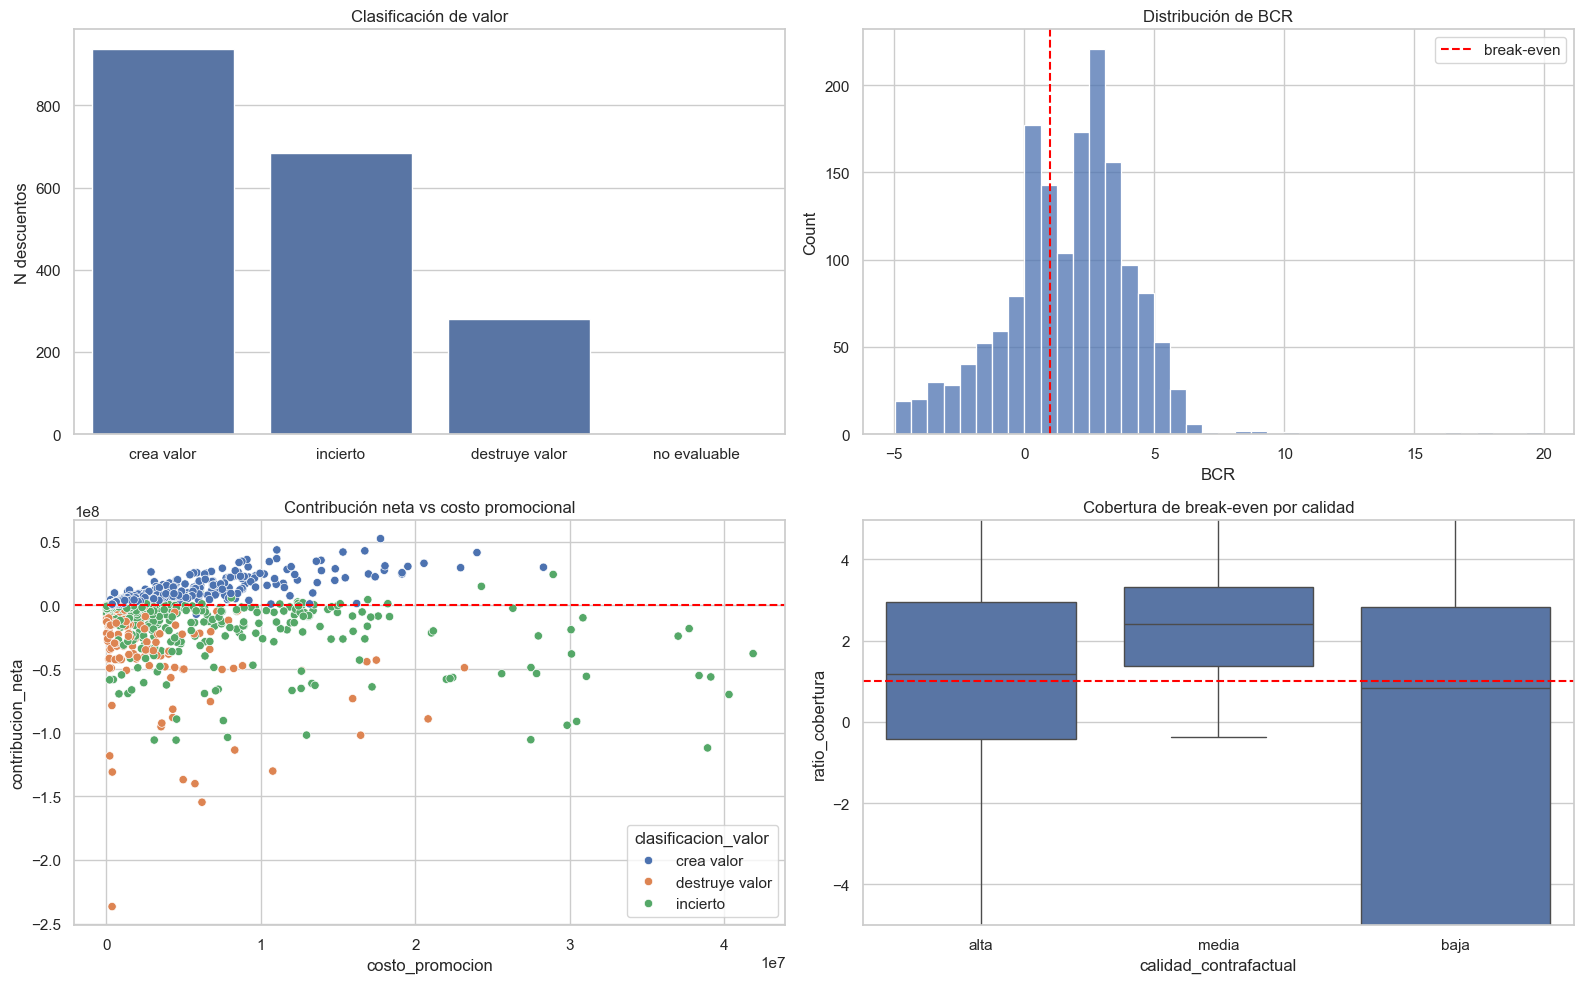

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

data_grafico = resultados_filtrados_df.copy()

sns.countplot(data=data_grafico, x="clasificacion_valor", order=["crea valor", "incierto", "destruye valor", "no evaluable"], ax=axes[0, 0])
axes[0, 0].set_title("Clasificación de valor")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("N descuentos")

sns.histplot(data=data_grafico.loc[data_grafico["BCR"].between(-5, 20)], x="BCR", bins=40, ax=axes[0, 1])
axes[0, 1].axvline(1, color="red", linestyle="--", label="break-even")
axes[0, 1].set_title("Distribución de BCR")
axes[0, 1].legend()

sns.scatterplot(data=data_grafico, x="costo_promocion", y="contribucion_neta", hue="clasificacion_valor", ax=axes[1, 0])
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_title("Contribución neta vs costo promocional")

sns.boxplot(data=data_grafico, x="calidad_contrafactual", y="ratio_cobertura", order=["alta", "media", "baja"], ax=axes[1, 1])
axes[1, 1].axhline(1, color="red", linestyle="--")
axes[1, 1].set_ylim(-5, data_grafico["ratio_cobertura"].quantile(0.95) if data_grafico["ratio_cobertura"].notna().any() else 5)
axes[1, 1].set_title("Cobertura de break-even por calidad")

plt.tight_layout()
plt.show()


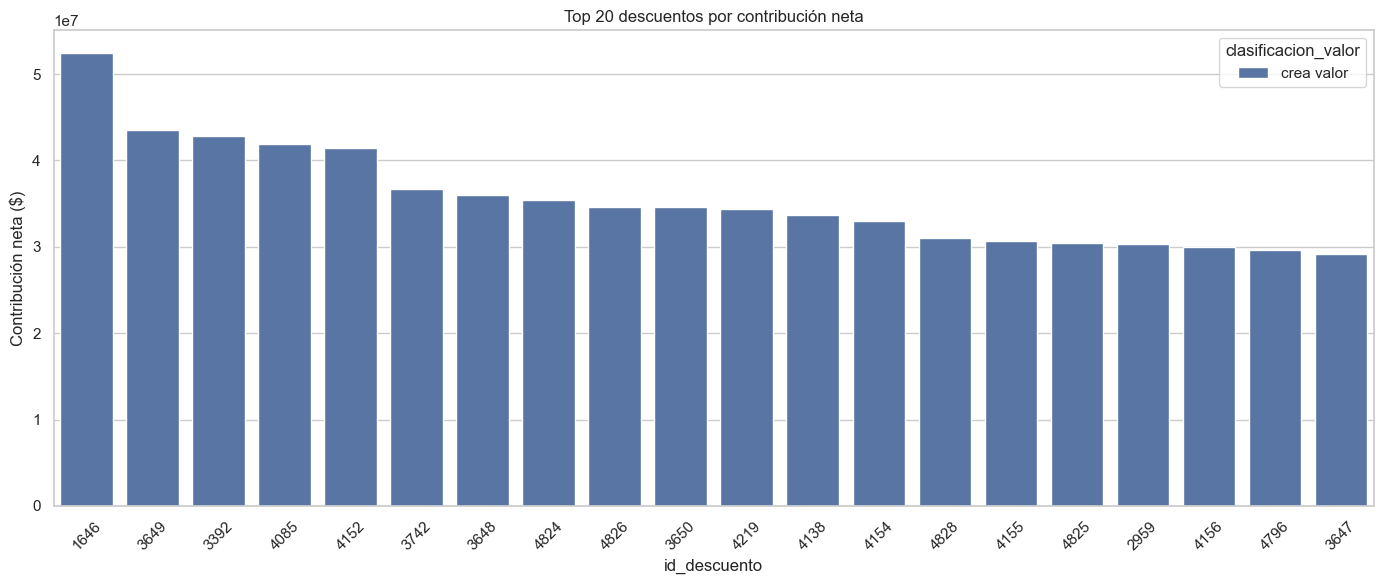

In [18]:
top_contribucion = resultados_filtrados_df.sort_values("contribucion_neta", ascending=False).head(20).copy()
top_contribucion["id_descuento"] = top_contribucion["id_descuento"].astype(str)

plt.figure(figsize=(14, 6))
sns.barplot(data=top_contribucion, x="id_descuento", y="contribucion_neta", hue="clasificacion_valor", dodge=False)
plt.title("Top 20 descuentos por contribución neta")
plt.xlabel("id_descuento")
plt.ylabel("Contribución neta ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Exportación reproducible

In [19]:
resultados_df.to_csv(OUTPUT_RAW, index=False)
resultados_filtrados_df.to_csv(OUTPUT_FILTRADO, index=False)
outliers_df.to_csv(OUTPUT_OUTLIERS, index=False)

print("Archivos exportados:")
print("-", OUTPUT_RAW)
print("-", OUTPUT_FILTRADO)
print("-", OUTPUT_OUTLIERS)


Archivos exportados:
- datos/resultados_retornos_raw_vs02.csv
- datos/resultados_retornos_filtrados_vs02.csv
- datos/outliers_retornos_vs02.csv
